In [7]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os
import librosa.display
import seaborn as sns
import IPython.display as ipd
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [8]:
gt=pd.read_csv("Data/features_3_sec.csv")
audio_path=r"Data/genres_original"
gt

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,rock.00099.5.wav,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
9986,rock.00099.6.wav,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
9987,rock.00099.7.wav,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock
9988,rock.00099.8.wav,66149,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,rock


In [9]:
gt=gt.drop(labels="filename",axis=1)
gt.shape

(9990, 59)

In [10]:
#description of the dataset  
print(gt.describe())

        length  chroma_stft_mean  chroma_stft_var     rms_mean       rms_var  \
count   9990.0       9990.000000      9990.000000  9990.000000  9.990000e+03   
mean   66149.0          0.379534         0.084876     0.130859  2.676388e-03   
std        0.0          0.090466         0.009637     0.068545  3.585628e-03   
min    66149.0          0.107108         0.015345     0.000953  4.379535e-08   
25%    66149.0          0.315698         0.079833     0.083782  6.145900e-04   
50%    66149.0          0.384741         0.085108     0.121253  1.491318e-03   
75%    66149.0          0.442443         0.091092     0.176328  3.130862e-03   
max    66149.0          0.749481         0.120964     0.442567  3.261522e-02   

       spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
count             9990.000000           9.990000e+03              9990.000000   
mean              2199.219431           4.166727e+05              2241.385959   
std                751.860611       

In [11]:
#check for null values
gt.isnull().sum()

length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var                  0
mfcc9_mean    

/var/folders/6b/97ymbbc127369zq_4ypgy8j80000gn/T/ipykernel_64070/3479738757.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(gt['label'],palette='twilight')


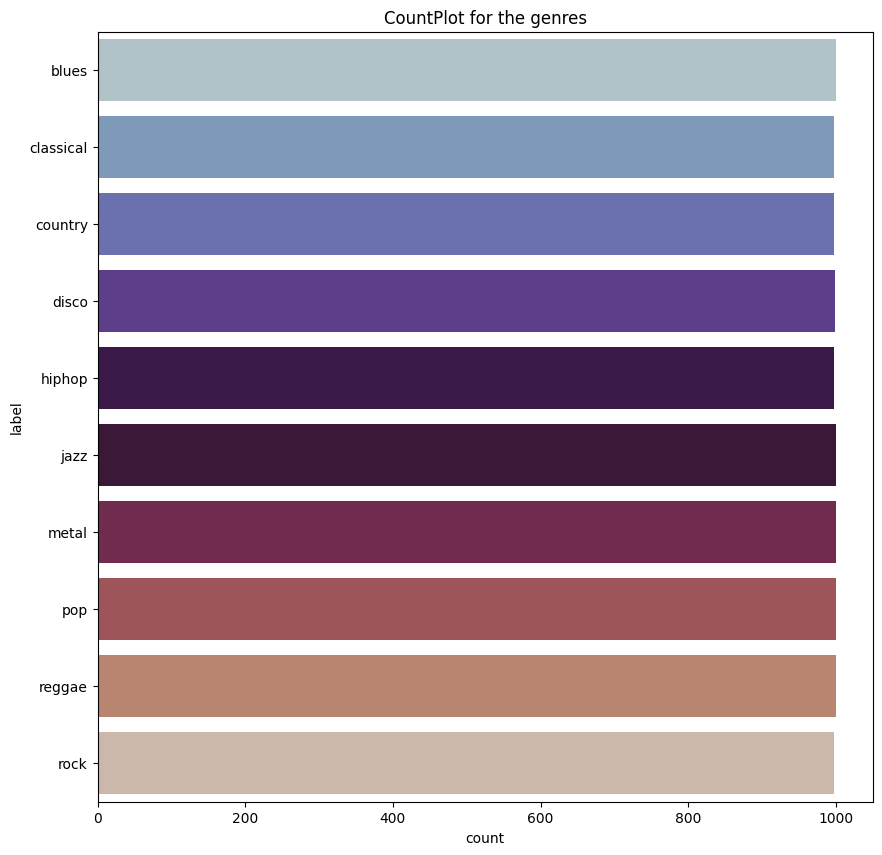

In [12]:
plt.figure(figsize=(10,10))
sns.countplot(gt['label'],palette='twilight')
plt.title("CountPlot for the genres")
plt.show()

In [13]:
cn=LabelEncoder()
cn_op=cn.fit_transform(gt['label'])
gt.drop("label",axis=1,inplace=True)
gt["label"]=cn_op
gt

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,0
1,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,0
2,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,0
3,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,0
4,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,3015.559458,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,9
9986,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,3746.694524,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,9
9987,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,2442.362154,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,9
9988,66149,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,4313.266226,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,9


In [16]:
d,s=librosa.load('Data/genres_original/blues/blues.00000.wav')
Audio(d,rate=s)

Sample No:  Data/genres_original/blues/blues.00000.wav


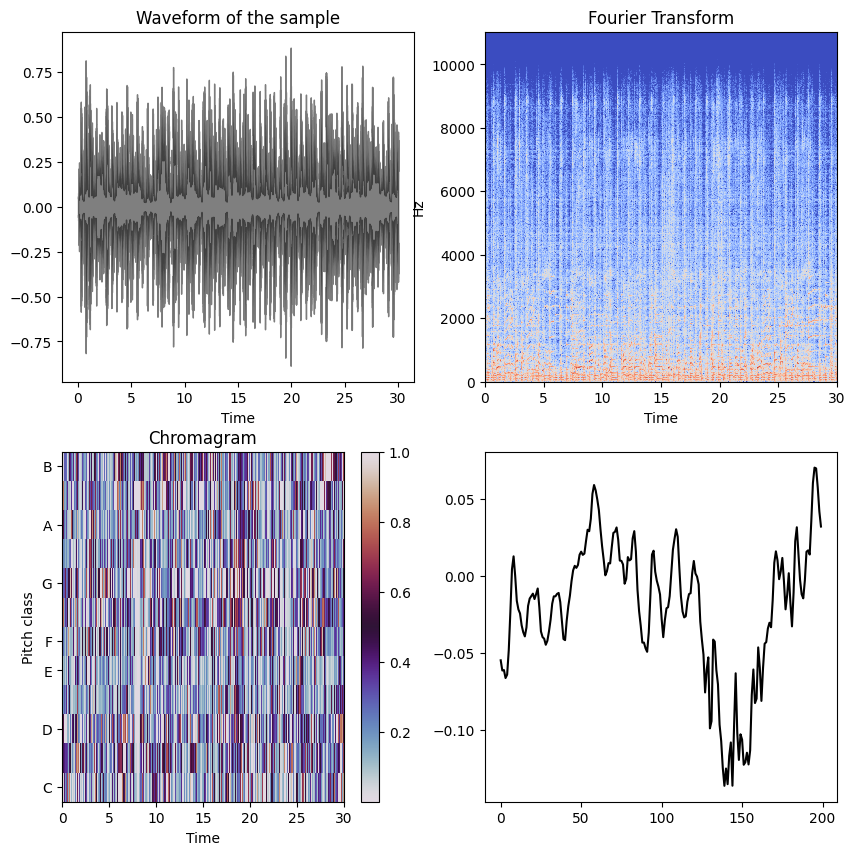

Sample No:  Data/genres_original/classical/classical.00000.wav


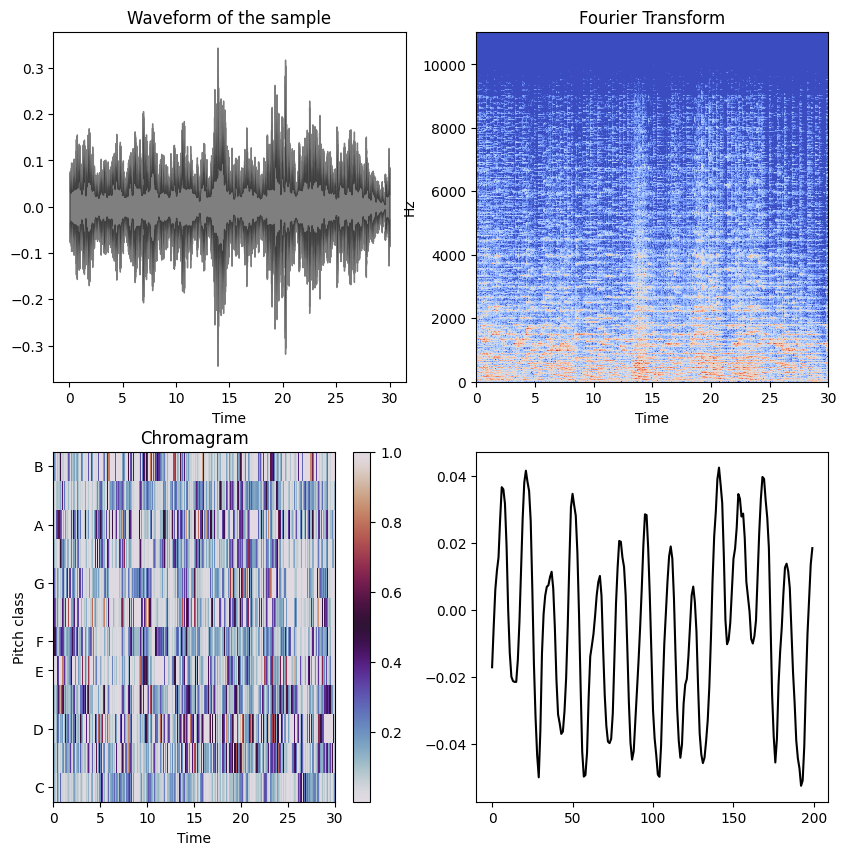

Sample No:  Data/genres_original/country/country.00000.wav


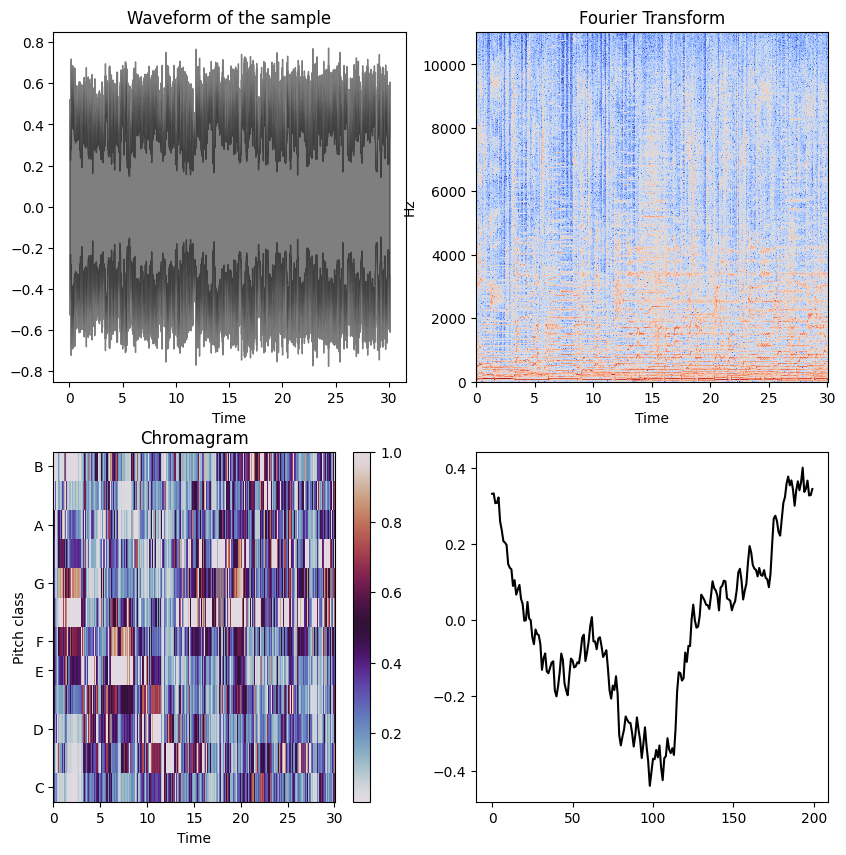

Sample No:  Data/genres_original/disco/disco.00000.wav


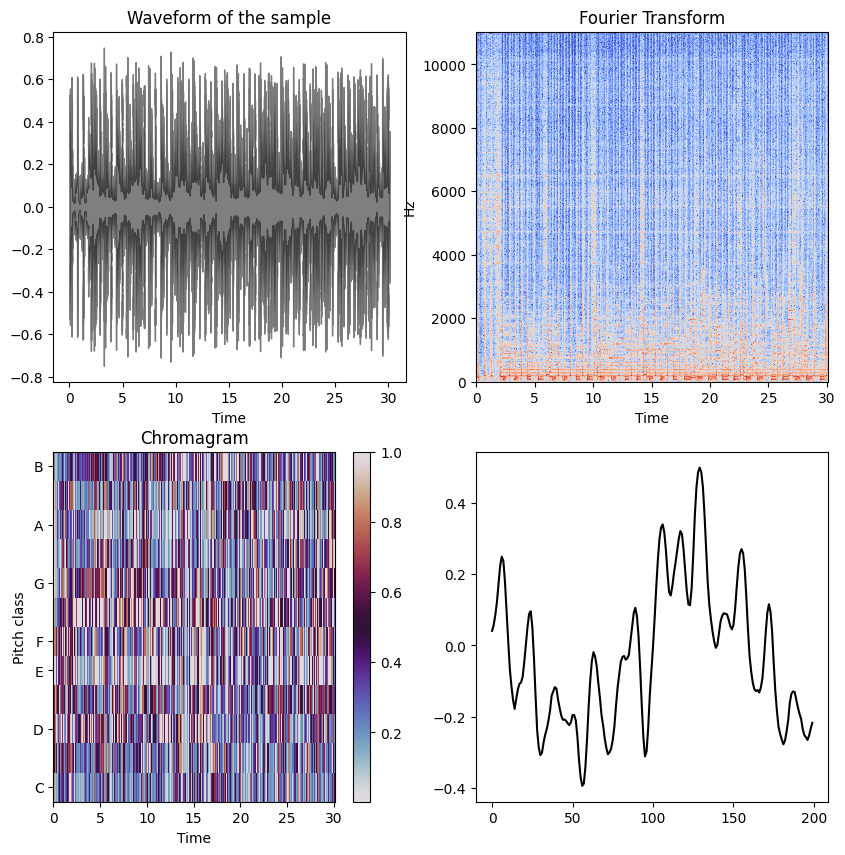

Sample No:  Data/genres_original/hiphop/hiphop.00000.wav


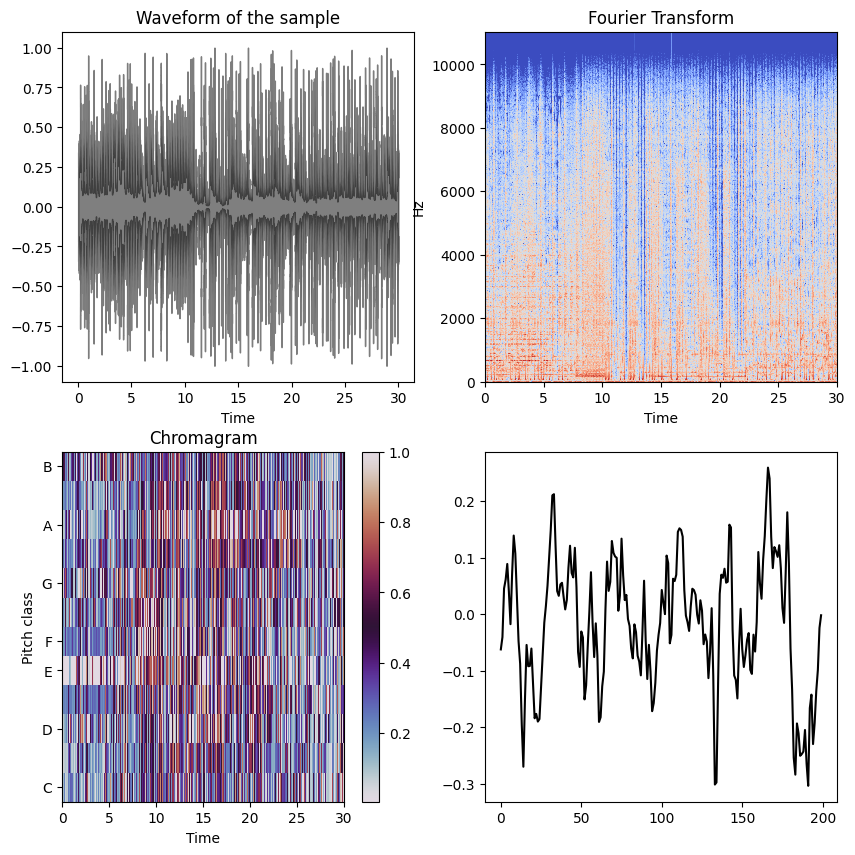

Sample No:  Data/genres_original/jazz/jazz.00000.wav


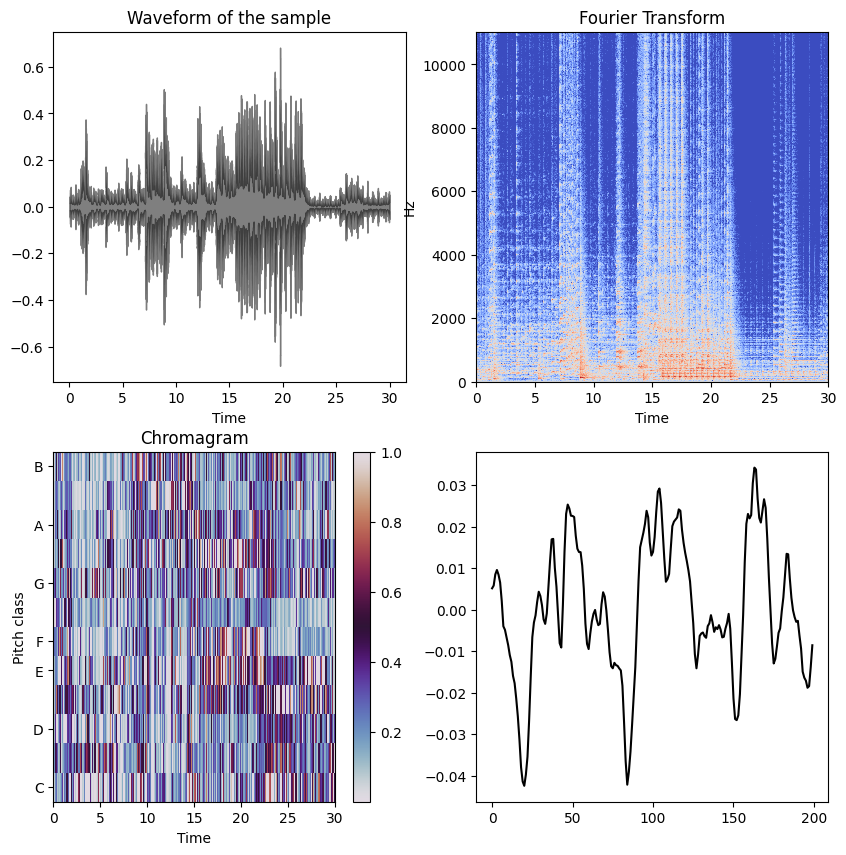

Sample No:  Data/genres_original/metal/metal.00000.wav


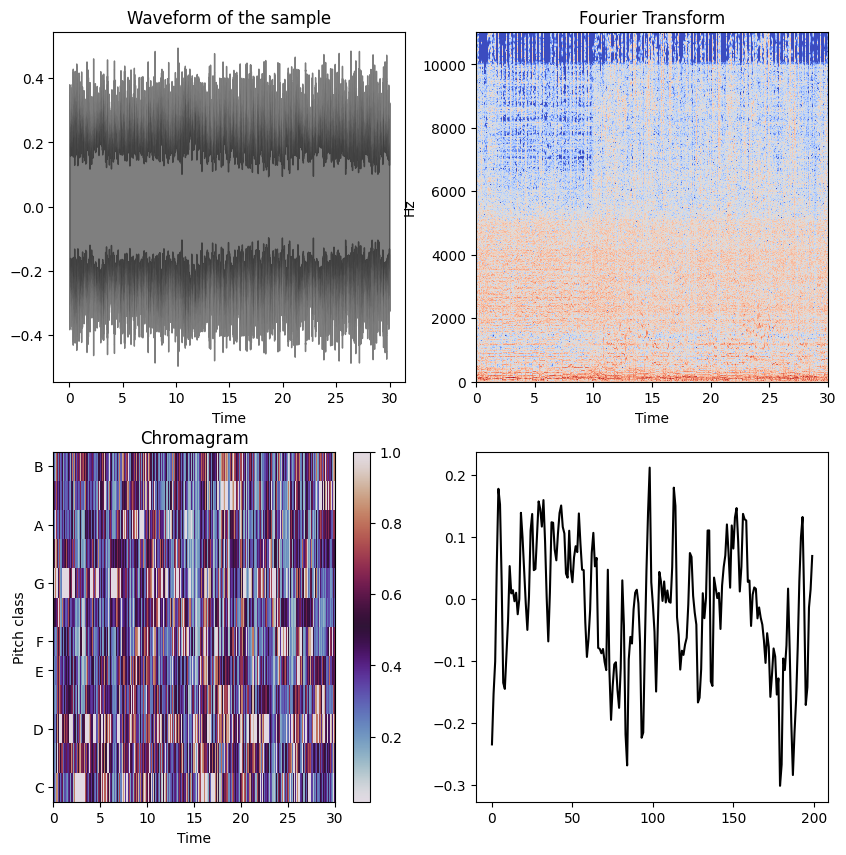

Sample No:  Data/genres_original/pop/pop.00000.wav


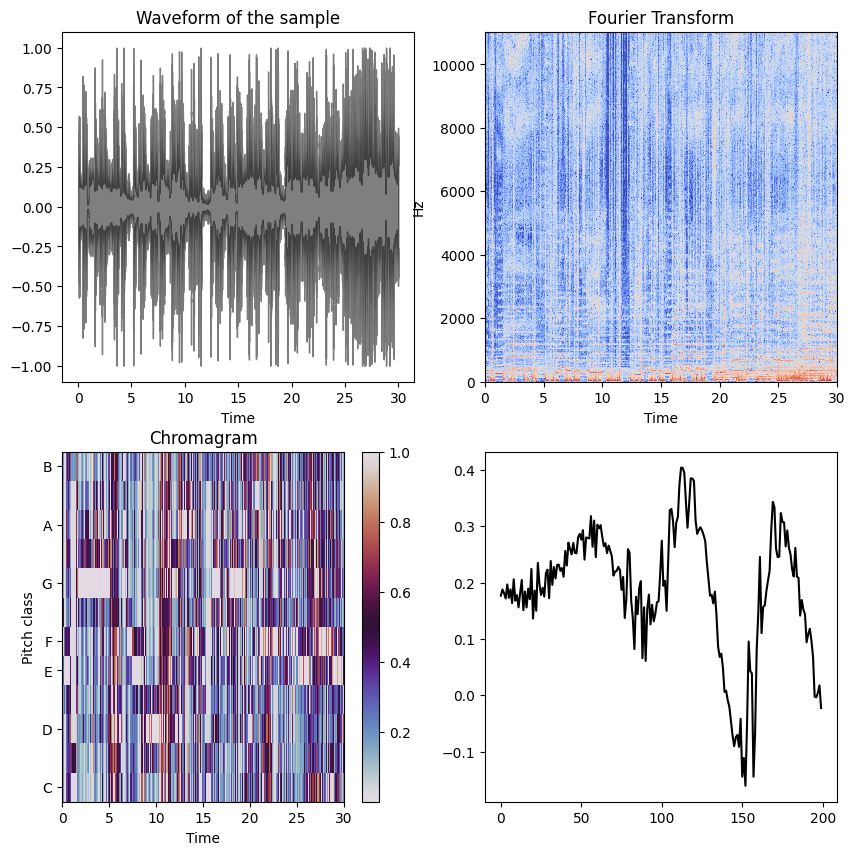

Sample No:  Data/genres_original/reggae/reggae.00000.wav


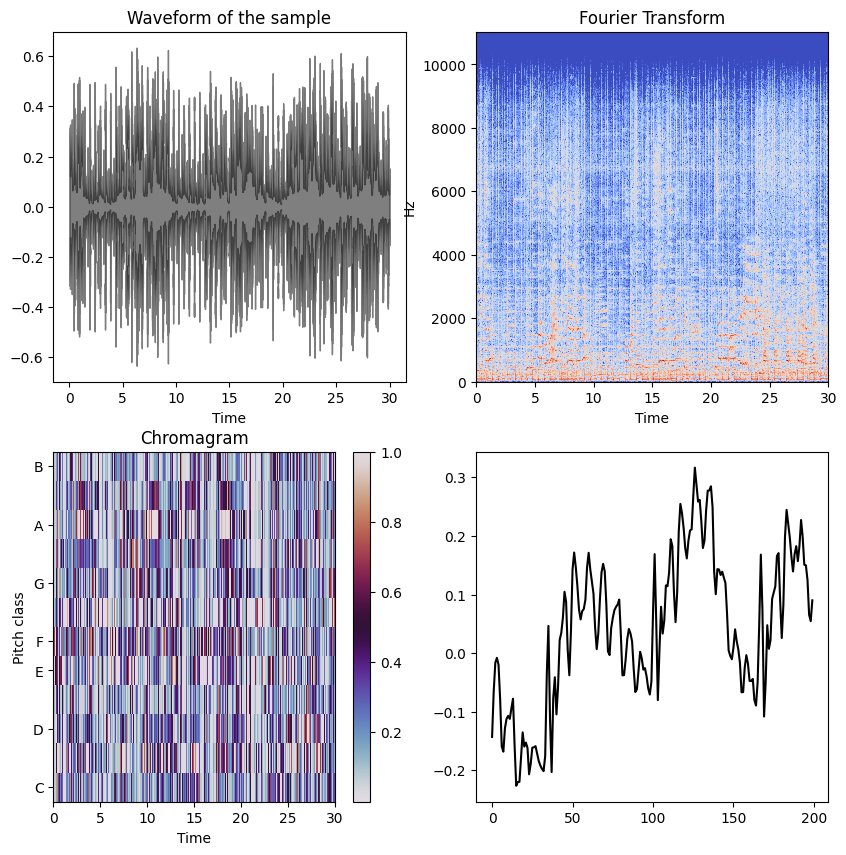

Sample No:  Data/genres_original/rock/rock.00000.wav


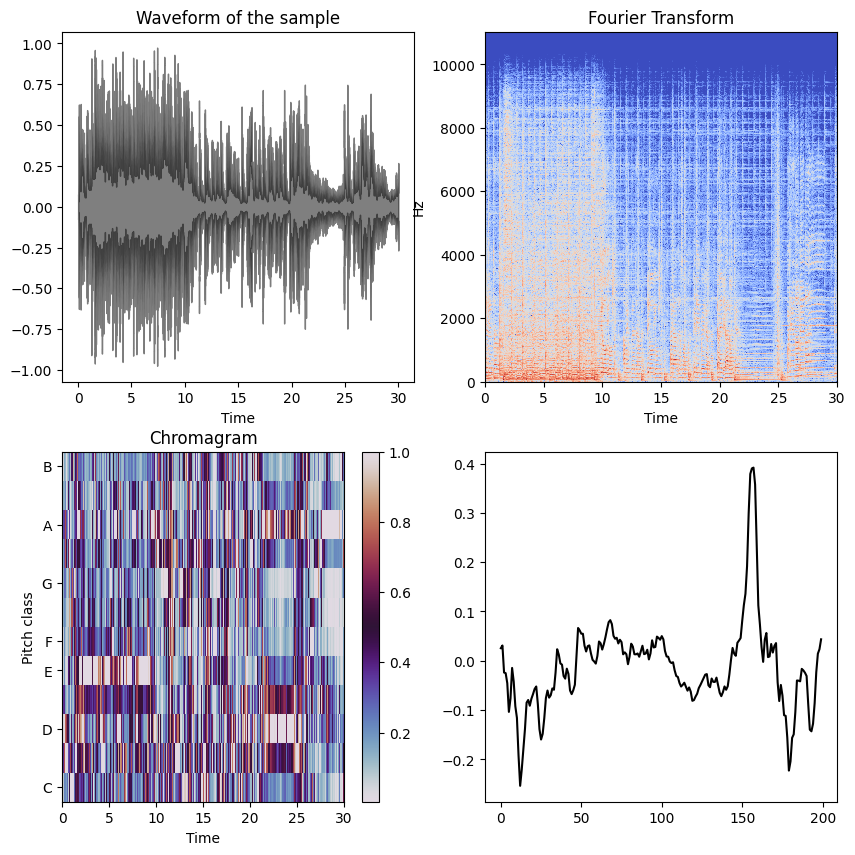

In [18]:
import IPython
files=['Data/genres_original/blues/blues.00000.wav','Data/genres_original/classical/classical.00000.wav',
       'Data/genres_original/country/country.00000.wav','Data/genres_original/disco/disco.00000.wav',
       'Data/genres_original/hiphop/hiphop.00000.wav','Data/genres_original/jazz/jazz.00000.wav',
       'Data/genres_original/metal/metal.00000.wav','Data/genres_original/pop/pop.00000.wav',
       'Data/genres_original/reggae/reggae.00000.wav','Data/genres_original/rock/rock.00000.wav']
for i in files:
  d,s=librosa.load(i)
  print("Sample No: ",i)
  plt.figure(figsize=(10,10))
  plt.subplot(2,2,1)
  librosa.display.waveshow(d,color="black", alpha = 0.5);plt.title("Waveform of the sample")
  plt.subplot(2,2,2)
  ft=librosa.amplitude_to_db(abs(librosa.stft(d)))
  librosa.display.specshow(ft,sr=s,x_axis='time',y_axis='hz'),plt.title("Fourier Transform")
  plt.subplot(2,2,3)
  cg=librosa.feature.chroma_stft(y=d,sr=s)#Chromagram from any waveform
  librosa.display.specshow(cg,sr=s,x_axis="time",y_axis="chroma",cmap="twilight");plt.colorbar();plt.title("Chromagram")
  plt.subplot(2,2,4)
  plt.plot(d[1000:1200],color="black")
  
  plt.show()

In [19]:
#preprocessing
ssr=StandardScaler()
x=np.array(gt.iloc[:,:-1],dtype=float)
x=ssr.fit_transform(x)
y=gt.iloc[:,-1]
print(x)

[[ 0.         -0.48780784  0.64052047 ... -0.51356204  0.12841417
  -0.29178072]
 [ 0.         -0.40314187  0.13183473 ...  1.01138445  1.27578001
   0.05642464]
 [ 0.         -0.36169428  0.7644909  ... -0.04624405  0.65390663
  -0.52145798]
 ...
 [ 0.         -0.35433044  0.42997426 ... -0.15370124  0.11765485
  -0.33882395]
 [ 0.          0.0883611  -0.00630133 ... -0.72456977  0.30333409
  -0.95893743]
 [ 0.         -0.11321002  0.19536324 ... -0.37245283 -0.47495901
  -0.55112155]]


In [20]:
#training testing
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.3)

Accuracy:  0.8838838838838838
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       297
           1       0.88      0.95      0.92       332
           2       0.78      0.85      0.81       309
           3       0.81      0.94      0.87       263
           4       0.91      0.87      0.89       291
           5       0.90      0.82      0.86       292
           6       0.96      0.97      0.96       274
           7       0.89      0.84      0.87       315
           8       0.91      0.92      0.91       326
           9       0.93      0.77      0.84       298

    accuracy                           0.88      2997
   macro avg       0.89      0.88      0.88      2997
weighted avg       0.89      0.88      0.88      2997



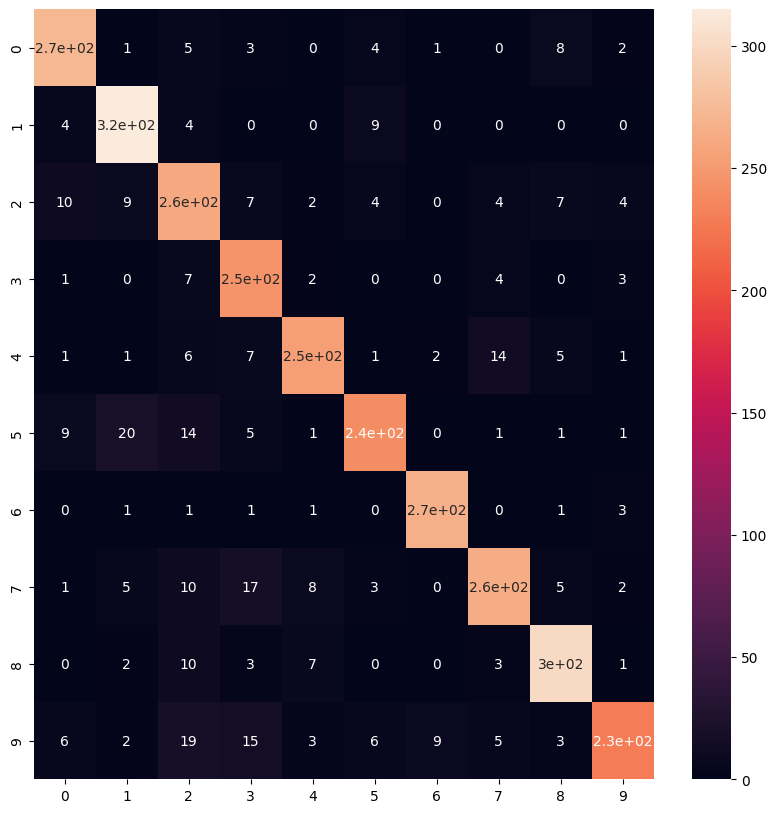

In [21]:
# Applying K nearest Neighbour algorithm to predict the results
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,Y_train)
knn_pred=knn.predict(X_test)
print("Accuracy: ",accuracy_score(Y_test,knn_pred))
print(classification_report(Y_test,knn_pred))
knn_cm=confusion_matrix(Y_test, knn_pred)
plt.figure(figsize=(10,10))
sns.heatmap(knn_cm,annot=True)
plt.show()

Accuracy:  0.8551885218551886
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       297
           1       0.91      0.98      0.94       332
           2       0.84      0.80      0.82       309
           3       0.76      0.85      0.80       263
           4       0.91      0.78      0.84       291
           5       0.87      0.91      0.89       292
           6       0.89      0.92      0.90       274
           7       0.87      0.87      0.87       315
           8       0.85      0.85      0.85       326
           9       0.79      0.73      0.76       298

    accuracy                           0.86      2997
   macro avg       0.85      0.85      0.85      2997
weighted avg       0.86      0.86      0.85      2997



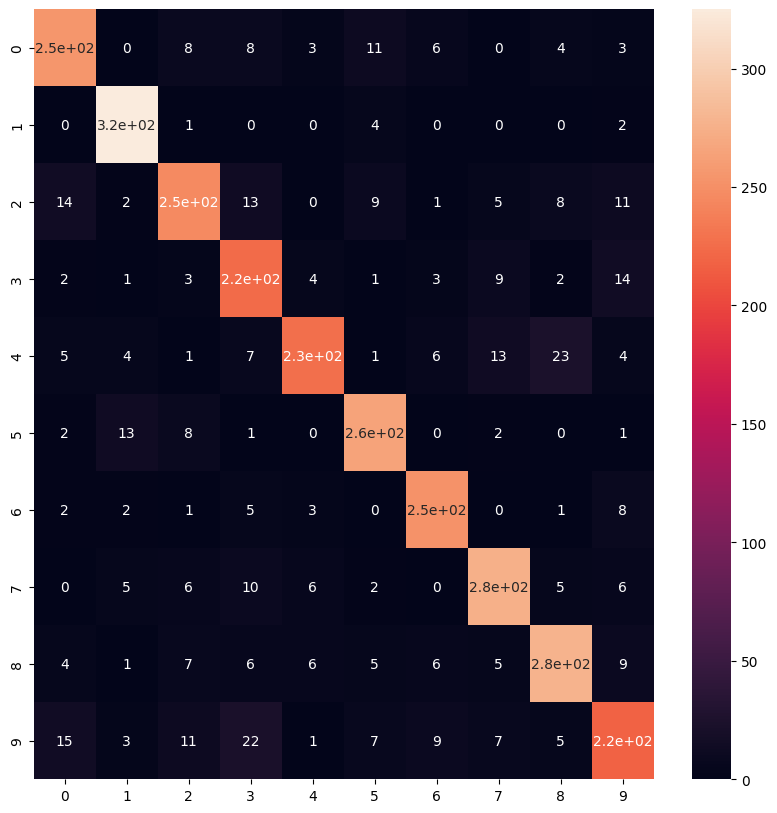

In [22]:
# Applying SVM algorithm to predict the results
svm=SVC(kernel='rbf', degree=8)
svm.fit(X_train,Y_train)
svm_pred=svm.predict(X_test)
print("Accuracy: ",accuracy_score(Y_test,svm_pred))
print(classification_report(Y_test,svm_pred))
svm_cm=confusion_matrix(Y_test,svm_pred)
plt.figure(figsize=(10,10))
sns.heatmap(svm_cm,annot=True)
plt.show()